In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
from google.colab import files

print("Silakan unggah file 'creditcard.csv' Anda:")
uploaded = files.upload()

Silakan unggah file 'creditcard.csv' Anda:


Saving creditcard.csv to creditcard.csv


In [ ]:
df = pd.read_csv('creditcard.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

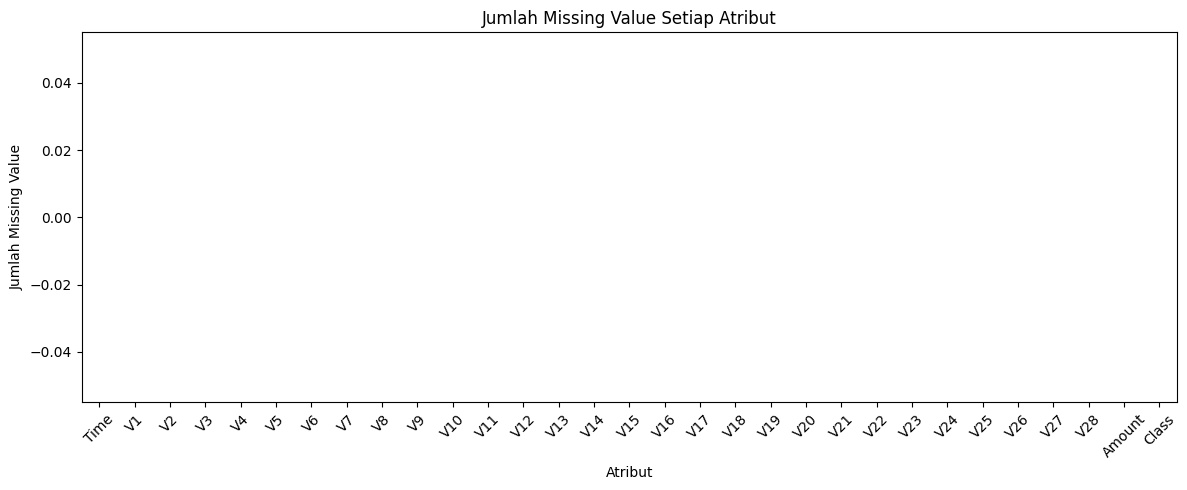


Jumlah Class:
Class
0    284315
1       492
Name: count, dtype: int64


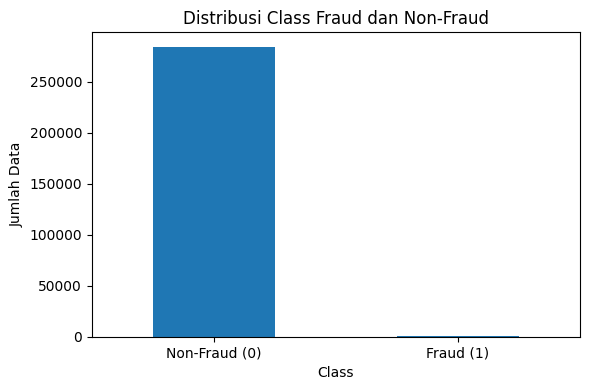

In [ ]:
import matplotlib.pyplot as plt
print("\nInformasi Dataset:")
df.info()

print("\nMissing Value:")
missing_values = df.isnull().sum()
print(missing_values)

plt.figure(figsize=(12,5))
missing_values.plot(kind='bar')

plt.title('Jumlah Missing Value Setiap Atribut')
plt.xlabel('Atribut')
plt.ylabel('Jumlah Missing Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nJumlah Class:")
class_counts = df['Class'].value_counts()
print(class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')

plt.title('Distribusi Class Fraud dan Non-Fraud')
plt.xlabel('Class')
plt.ylabel('Jumlah Data')
plt.xticks([0,1], ['Non-Fraud (0)', 'Fraud (1)'], rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

print("\n5 Data Pertama Sebelum Normalisasi:")
print(X.head())

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

print("\nData berhasil dinormalisasi")

X_normalized_df = pd.DataFrame(X_normalized, columns=X.columns)

print("\n5 Data Pertama Sesudah Normalisasi:")
print(X_normalized_df.head())


comparison_df = pd.concat(
    [
        X.head().reset_index(drop=True),
        X_normalized_df.head().reset_index(drop=True)
    ],
    axis=1,
    keys=['Sebelum Normalisasi', 'Sesudah Normalisasi']
)

print("\nPerbandingan Data Sebelum dan Sesudah Normalisasi:")
print(comparison_df)


5 Data Pertama Sebelum Normalisasi:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267

In [ ]:
fitur_penting = ['Time', 'Amount']

skala_ringkas = pd.DataFrame({
    'Min Sebelum': X[fitur_penting].min(),
    'Max Sebelum': X[fitur_penting].max(),
    'Min Sesudah': X_normalized_df[fitur_penting].min(),
    'Max Sesudah': X_normalized_df[fitur_penting].max()
})

print("\nSkala Fitur Time dan Amount:")
print(skala_ringkas)


Skala Fitur Time dan Amount:
        Min Sebelum  Max Sebelum  Min Sesudah  Max Sesudah
Time            0.0    172792.00          0.0          1.0
Amount          0.0     25691.16          0.0          1.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y,
    test_size=0.2,
    random_state=42
)

print("\nJumlah Data Training :", X_train.shape[0])
print("Jumlah Data Testing  :", X_test.shape[0])


Jumlah Data Training : 227845
Jumlah Data Testing  : 56962


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)


print("\n10 Data Class Aktual (Testing):")
print(y_test.head(10))

print("\n10 Hasil Prediksi KNN:")
print(y_pred[:10])

hasil_klasifikasi = pd.DataFrame({
    'Class_Aktual': y_test.values,
    'Class_Prediksi': y_pred
})

print("\nPerbandingan Aktual dan Prediksi (10 Data Pertama):")
print(hasil_klasifikasi.head(10))


10 Data Class Aktual (Testing):
43428     1
49906     0
29474     0
276481    0
278846    0
101565    0
260880    0
214337    0
201575    0
81055     0
Name: Class, dtype: int64

10 Hasil Prediksi KNN:
[1 0 0 0 0 0 0 0 0 0]

Perbandingan Aktual dan Prediksi (10 Data Pertama):
   Class_Aktual  Class_Prediksi
0             1               1
1             0               0
2             0               0
3             0               0
4             0               0
5             0               0
6             0               0
7             0               0
8             0               0
9             0               0


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[56862     2]
 [   24    74]]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)


Accuracy:
0.9995435553526912


In [ ]:
precision = precision_score(y_test, y_pred)

print("\nPrecision:")
print(precision)


Precision:
0.9736842105263158


In [ ]:
recall = recall_score(y_test, y_pred)

print("\nRecall:")
print(recall)


Recall:
0.7551020408163265


In [ ]:
f1 = f1_score(y_test, y_pred)

print("\nF1-Score:")
print(f1)


F1-Score:
0.8505747126436781


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



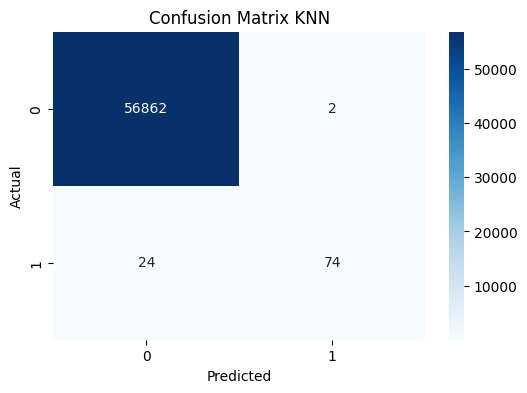

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()